분류의 성능 평가 지표로
Accuracy, Confusion Matrix, Precision, Recall,F1 score, ROC AUC가 있고
Accuracy는 직관적으로 모델 예측성능 나타낼수있지만 데이터 구성에 따라 성능을 왜곡할수있음

In [2]:
from sklearn.base import BaseEstimator
#BaseEstimator 클래스 상속받아 성별에 따라 생존자 예측하는 분류 생성
class MyDummyClassifier(BaseEstimator):
    #fit()메서드는 아무것도 학습하지 않음
    def fit(self,X,y=None):
        pass

    #predict()메서드는 단순히 sex 피처가 1이면 0, 그렇지 않으면 1로 예측함
    def predict(self,X):
        pred=np.zeros((X.shape[0],1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i]==1:
                pred[i]=0
            else:
                pred[i]=1
        return pred
 # 1. Null 처리 함수 
def fillna(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['Cabin'] = df['Cabin'].fillna('N')
    df['Embarked'] = df['Embarked'].fillna('N')
    df['Fare'] = df['Fare'].fillna(0)
    return df
# 2. 머신러닝 알고리즘에 불필요한 속성 제거 
def drop_features(df):
    df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
    return df
# 3. 레이블 인코딩 수행 
def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df
# 4. 앞에서 설정한 데이터 전처리 함수들을 하나로 묶어주는 함수
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

#원본 데이터를 재로딩,데이터가공,학습데이터/테스트 데이터 분할
titanic_df=pd.read_csv('train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
X_titanic_df=transform_features(X_titanic_df)
X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=0)

#위에서 생성한 dummy classifier를 이용해 학습 예측 평가 수행
myclf=MyDummyClassifier()
myclf.fit(X_train,y_train)

mypredictions=myclf.predict(X_test)
print('dummy classifier의 정확도는:{0:.4f}'.format(accuracy_score(y_test,mypredictions)))



dummy classifier의 정확도는:0.7877


In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass
    #입력값으로 들어오는 X데이터 세트의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)
#사이킷런의 내장 데이터 세트인 load_digits()를 이용해 MNIST 데이터 로딩
digits=load_digits()

#digits 번호가 7번이면 True 이고 이를 astype(int)로 1로변환, 7번이 아니면 False이고 0으로 변환
y=(digits.target==7).astype(int)
X_train,X_test,y_train,y_test=train_test_split(digits.data,y,random_state=11)

In [7]:
#불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 세트 크기:',y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

#Dummy Classifier로 학습 예측 정확도 평가
fakeclf=MyFakeClassifier()
fakeclf.fit(X_train,y_train)
fakepred=fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


오차행렬
이진분류의 예측오류가 얼마인지와 어떤 유형의 예측오류가 발생하는지 나타내는 지표
TN:N로 예측했고 실제값도 N
TP:P로 예측,실제값도 P
FN:N로 예측, 실제값은 P
FP:P로 예측, 실제값은 N


In [8]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,fakepred)



array([[405,   0],
       [ 45,   0]])

정밀도와 재현율
정밀도=TP/(FP+TP)
재현율=TP/(FN+TP)

In [9]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix
def get_clf_eval(y_test,pred):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f}'.format(accuracy,precision,recall))

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#원본 데이터를 재로딩,데이터가공,학습데이터/테스트 데이터 분할
titanic_df=pd.read_csv('train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
X_titanic_df=transform_features(X_titanic_df)
X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,test_size=0.20,random_state=11)

lr_clf=LogisticRegression(solver='liblinear')
lr_clf.fit(X_train,y_train)
pred=lr_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도:0.8659,정밀도:0.8246,재현율:0.7705


In [ ]:
pred_proba=lr_clf.predict_proba(X_test)
pred=lr_clf.predict(X_test)
print('pred_proba()결과 shape:{0}'.format(pred_proba.shape))
print('pred_proba array에서 앞3개만 샘플로 추출\n:',pred_proba[:3])

#예측확률 array와 예측결과값 array를 병합해 예측확률과 결과값을 한눈에 확인
pred_proba_result=np.concatenate([pred_proba,pred.reshape(-1,1)],axis=1)
print('두개의 class중에서 더 큰 확률을 클래스값으로 예측\n',pred_proba_result[:3])


pred_proba()결과 shape:(179, 2)
pred_proba array에서 앞3개만 샘플로 추출
: [[0.44935226 0.55064774]
 [0.86335512 0.13664488]
 [0.86429644 0.13570356]]
두개의 class중에서 더 큰 확률을 클래스값으로 예측
 [[0.44935226 0.55064774 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429644 0.13570356 0.        ]]


In [13]:
from sklearn.preprocessing import Binarizer

X=[[1,-1,2],[2,0,0],[0,1.1,1.2]]
#X의 개별 원소들이 threshold값보다 같거나 작으면0을 크면 1을 반환
binarizer=Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [14]:
from sklearn.preprocessing import Binarizer
#Binarizer의 threshodl 설정값.분류결정 임계값
custom_threshold=0.5

#predict_proba()반환값의 두번째칼럼, 즉 positive 클래스 칼럼하나만 추출해 binarizer 적용
pred_proba_1=pred_proba[:,1].reshape(-1,1)

binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict=binarizer.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도:0.8659,정밀도:0.8246,재현율:0.7705


In [16]:
#Binarizer의 threshodl 설정값을 0.4로 설정 임계값을 낮춤
custom_threshold=0.4
pred_proba_1=pred_proba[:,1].reshape(-1,1)
binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict=binarizer.transform(pred_proba_1)

get_clf_eval(y_test,custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도:0.8212,정밀도:0.7042,재현율:0.8197


In [17]:
#테스트를 수행할 모든 임계값을 리스트 객체로 저장
thresholds=[0.4,0.45,0.50,0.55,0.60]

def get_eval_by_threshold(y_test,pred_proba_c1,thresholds):
    #thresholds list 객체 내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer=Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict=binarizer.transform(pred_proba_c1)
        print('임계값',custom_threshold)
        get_clf_eval(y_test,custom_predict)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임계값 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도:0.8212,정밀도:0.7042,재현율:0.8197
임계값 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도:0.8547,정밀도:0.7869,재현율:0.7869
임계값 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도:0.8659,정밀도:0.8246,재현율:0.7705
임계값 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도:0.8715,정밀도:0.8654,재현율:0.7377
임계값 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도:0.8771,정밀도:0.8980,재현율:0.7213


In [18]:
from sklearn.metrics import precision_recall_curve
#레이블 값이 1일때의 예측확률을 추출
pred_proba_class1=lr_clf.predict_proba(X_test)[:,1]

#실제값 데이터세트와 레이블값이 1일때의 예측확률을 precision_recall_curve 인자로 입력
precisions,recalls,thresholds=precision_recall_curve(y_test,pred_proba_class1)
print('반환된 분류 결정임계값 배열의 shpae:',thresholds.shape)

#반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되 임계값을 15step 추출
thr_index=np.arange(0,thresholds.shape[0],15)
print('샘플 추출을 위한 임계값 배열의 index 10개:,',thr_index)
print('샘플용 10개의 임계값: ',np.round(thresholds[thr_index],2))

#15step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도:',np.round(precisions[thr_index],3))
print('샘플 임계값별 재현율:',np.round(recalls[thr_index],3))

반환된 분류 결정임계값 배열의 shpae: (165,)
샘플 추출을 위한 임계값 배열의 index 10개:, [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임계값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도: [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율: [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


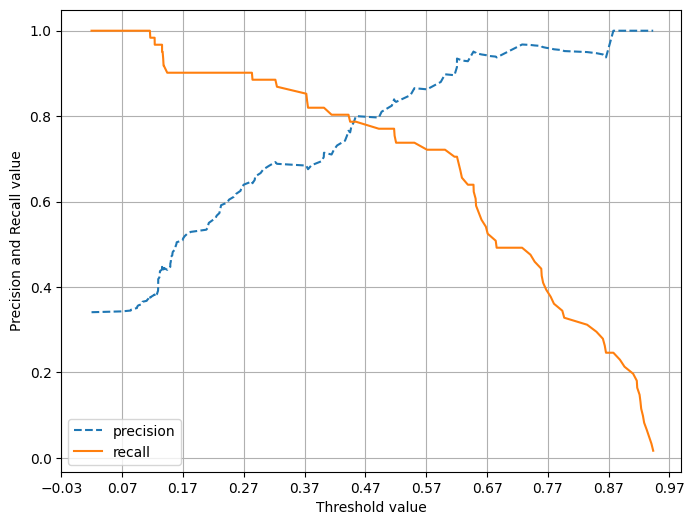

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 이 threshold 에 따른 정밀도,재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    # x축을 threshold값으로, y축은  정밀도, 재현율값으로 각각 plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')
    # threshold 값 x축의 scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start,end,0.1),2))
    # x축, y축 label과 legend, grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:,1])

F1 score

In [20]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,pred)
print('F1 스코어:{0:4f}'.format(f1))

F1 스코어:0.796610


In [21]:
def get_clf_eval(y_test,pred):
    confusion=confusion_matrix(y_test,pred)
    accuracy=accuracy_score(y_test,pred)
    precision=precision_score(y_test,pred)
    recall=recall_score(y_test,pred)
    #F1 스코어 추가
    f1=f1_score(y_test,pred)
    print('오차 행렬')
    print(confusion)
    #f1 score print 추가
    print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f}'.format(accuracy,precision,recall))
thresholds=[0.4,0.45,0.50,0.55,0.60]
pred_proba=lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)
    

임계값 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도:0.8212,정밀도:0.7042,재현율:0.8197
임계값 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도:0.8547,정밀도:0.7869,재현율:0.7869
임계값 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도:0.8659,정밀도:0.8246,재현율:0.7705
임계값 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도:0.8715,정밀도:0.8654,재현율:0.7377
임계값 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도:0.8771,정밀도:0.8980,재현율:0.7213


ROC AUC

In [23]:
from sklearn.metrics import roc_curve
#레이블 값이 1일떄의 예측 확률을 추출
pred_proba_class1=lr_clf.predict_proba(X_test)[:,1]

fprs,tprs,thresholds=roc_curve(y_test,pred_proba_class1)
#반환된 임계값 배열에서 샘플로 데이터를 추출하되, 임계값을 5step으로 추출
#thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arnage는 1부터 시작
thr_index=np.arange(1,thresholds.shape[0],5)
print('샘플 추출을 위한 임계값 배열의 index:',thr_index)
print('샘플 Index로 추출한 임계값',np.round(thresholds[thr_index],2))

#5 step 단위로 추출된 임계값에 따른 fpr,tpr 값
print('샘플 임계값별 FPR: ',np.round(fprs[thr_index],3))
print('샘플 임계값별 TPR: ',np.round(tprs[thr_index],3))

샘플 추출을 위한 임계값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 Index로 추출한 임계값 [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임계값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임계값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


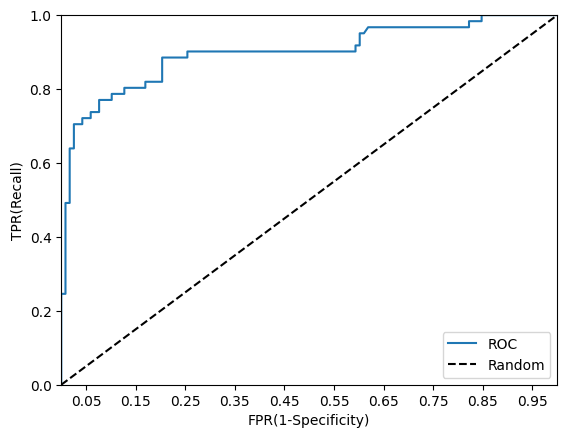

In [24]:
def roc_curve_plot(y_test, pred_proba_c1):
    # 임곗값에 따른 FPR,TPR 값을 반환받음
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    # ROC 곡선을 그래프 곡선으로 그림
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선을 그림
    plt.plot([0,1],[0,1],'k--',label='Random')


    # FPR X축의 Scale을 0.1 단위로 변경, X,Y축 명 설정
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))
    plt.xlim(0,1); plt.ylim(0,1)
    plt.xlabel('FPR(1-Specificity)'); plt.ylabel('TPR(Recall)')
    plt.legend()

roc_curve_plot(y_test, pred_proba[:,1])

In [25]:
from sklearn.metrics import roc_auc_score
pred_proba=lr_clf.predict_proba(X_test)[:,1]
roc_score=roc_auc_score(y_test,pred_proba)
print('ROC AUC값: {0:.4f}'.format(roc_score))

ROC AUC값: 0.8987


In [26]:
def get_clf_eval(y_test,pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC_AUC print 추가
    print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f},AUC:{4:.4f}'.format(accuracy, precision,recall,f1,roc_auc))